# Decision Trees using the Titanic Dataset

In this notebook, we'll learn how Decision Trees work, understand concepts like Entropy, Gini Impurity, Information Gain, and visualize how a Decision Tree makes predictions.

We'll also compare different tree depths to understand Underfitting and Overfitting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("/content/Titanic-Dataset.csv")

In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
data["Age"]=data["Age"].fillna(data["Age"].mean())

In [8]:
data=data.drop(
    ["PassengerId","Name","Ticket","Cabin"],
    axis=1
)

In [9]:
data["Embarked"]=data["Embarked"].fillna(
    data["Embarked"].mode()[0]
)

In [10]:
data["Embarked"]=data["Embarked"].fillna(
    data["Embarked"].mode()[0]
)

In [11]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in ["Sex","Embarked"]:
    data[col]=le.fit_transform(data[col])

In [17]:
from sklearn.model_selection import train_test_split

X=data.drop("Survived",axis=1)
y=data["Survived"]
X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.2,

random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(

criterion="gini",

random_state=42

)

model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
pred=model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)

0.7932960893854749

In [26]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,pred)

array([[86, 19],
       [18, 56]])

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       105
           1       0.75      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



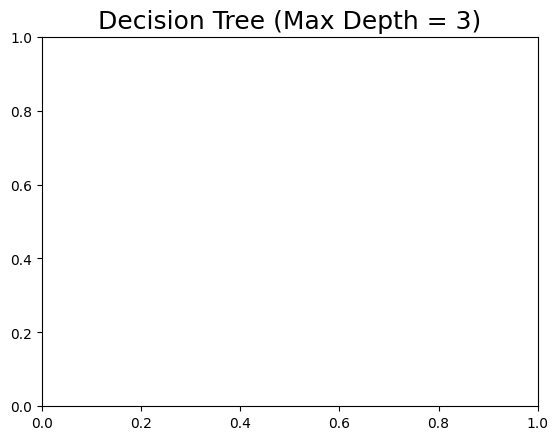

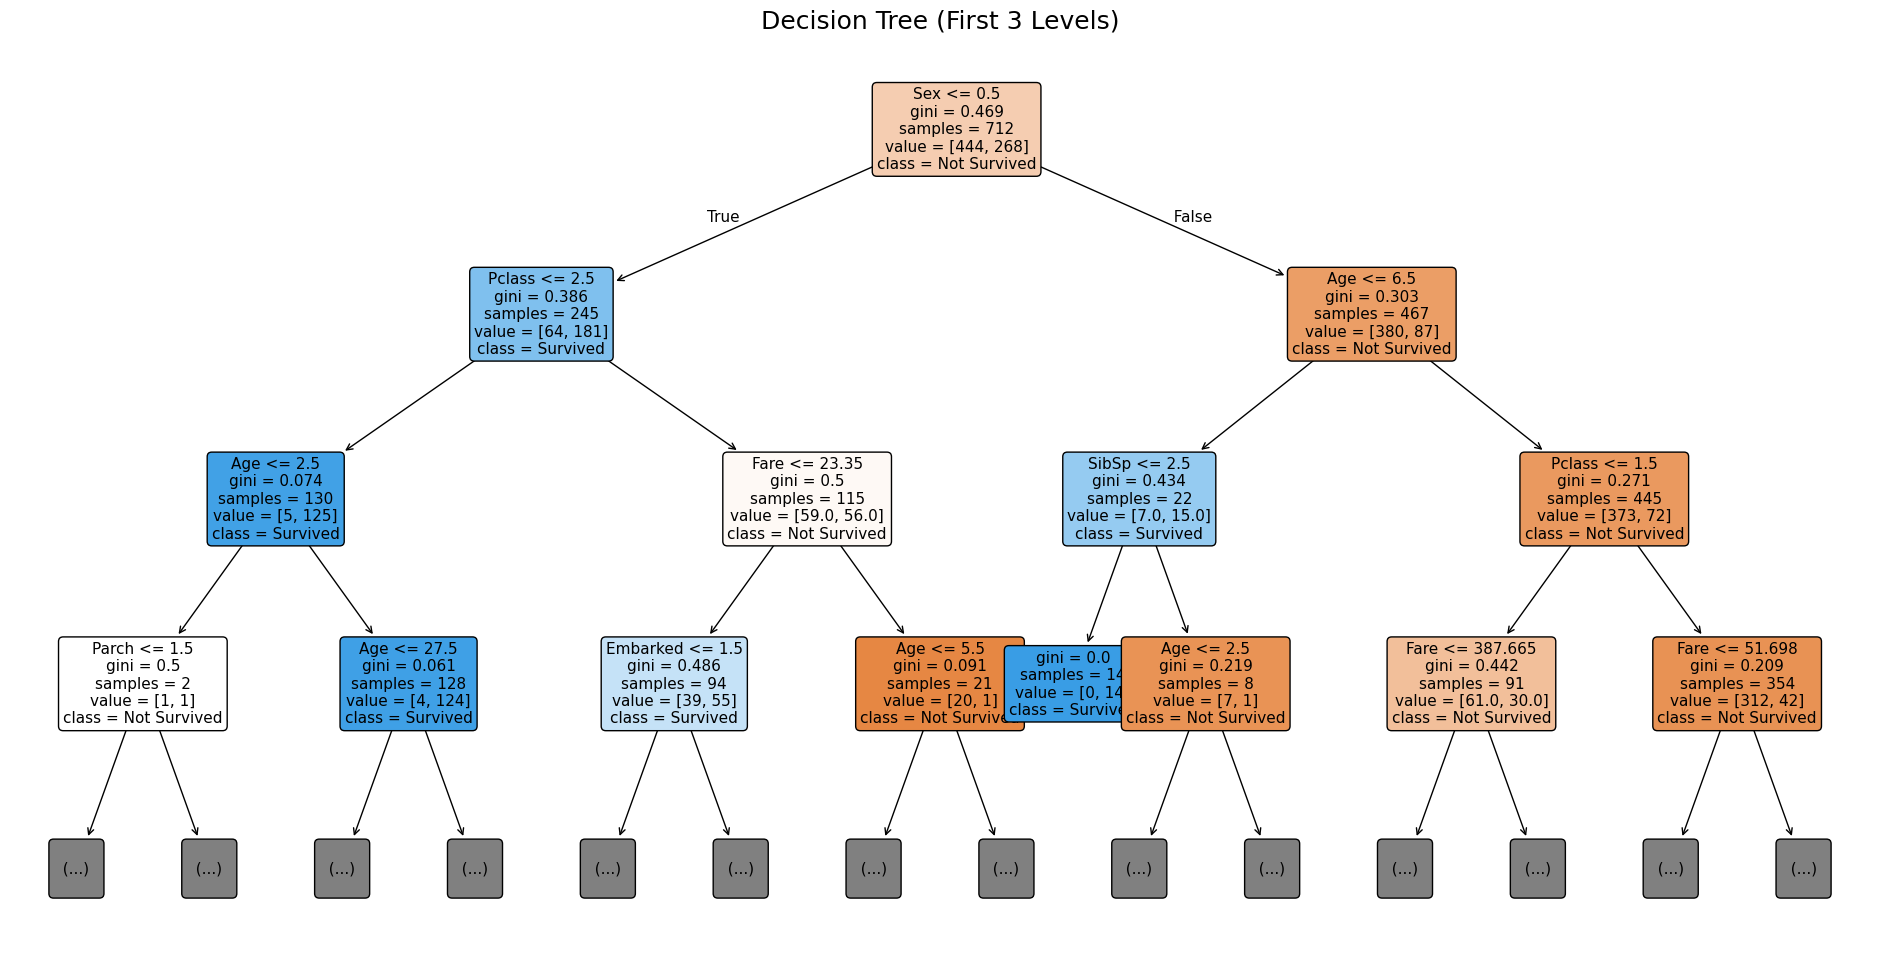

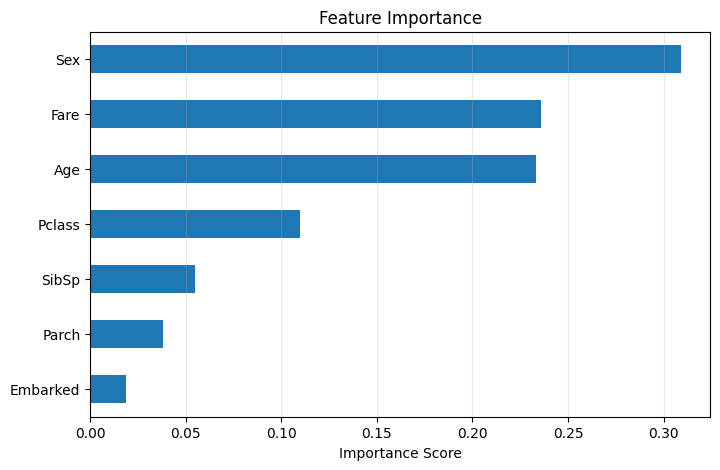

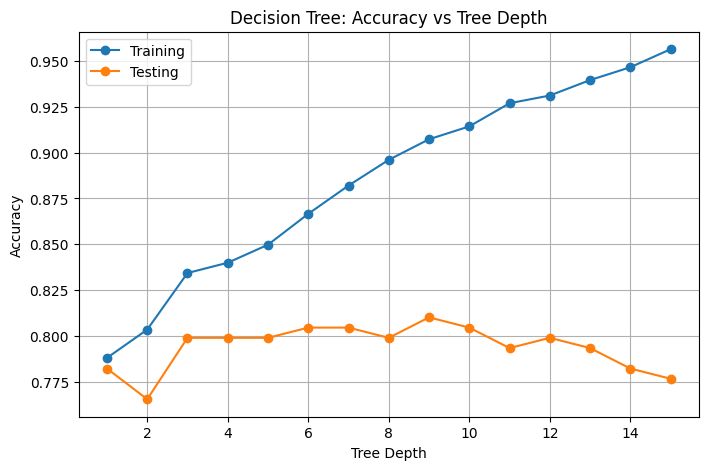

Best Depth: 9
Best Test Accuracy: 0.810


In [33]:
from sklearn.tree import plot_tree
plt.title("Decision Tree (Max Depth = 3)", fontsize=18)
plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=11,
    max_depth=3
)

plt.title("Decision Tree (First 3 Levels)", fontsize=18)
plt.show()
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.grid(axis="x", alpha=0.3)

plt.show()
depths = range(1, 16)

train_acc = []
test_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(8,5))

plt.plot(depths, train_acc, marker='o', label="Training")
plt.plot(depths, test_acc, marker='o', label="Testing")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

best_depth = depths[np.argmax(test_acc)]
best_acc = max(test_acc)

print(f"Best Depth: {best_depth}")
print(f"Best Test Accuracy: {best_acc:.3f}")


Interpretation of Tree Depth

Depth 1–2 (Underfitting)

Tree is too simple.
High Bias.
Both training and testing accuracy remain low.

Depth 6–9 (Optimal Model)

Best balance between complexity and generalization.
Highest testing accuracy (~81%).
Suitable depth for deployment.

Depth 10–15 (Overfitting)

Training accuracy continues to improve.
Testing accuracy begins to decline.
Model starts memorizing the training data instead of learning general patterns.

The model identified Sex as the most influential feature in predicting survival, followed by Fare and Age. Embarked contributed the least to the model's decisions.

As tree depth increases, the model becomes more complex and fits the training data better. However, beyond a certain depth, test accuracy begins to decline, indicating that the model is memorizing the training data rather than generalizing to unseen data.

## Conclusion

- Built a Decision Tree classifier on the Titanic dataset.
- Preprocessed missing values and encoded categorical variables.
- Achieved approximately 79% test accuracy.
- Visualized the first three levels of the tree for interpretability.
- Identified Sex, Fare, and Age as the most important predictive features.
- Analyzed how tree depth affects model performance.
- Demonstrated both underfitting (shallow trees) and overfitting (deep trees), highlighting the importance of selecting an appropriate model complexity.